<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        📋 Ecommerce Customer Experience 🎯
    </h1>
</div>


# 📂 Overview

* **Background** <br>
  In today’s competitive e-commerce landscape, understanding customer behavior is essential for improving **sales performance**, **customer retention**, and **service quality**. Businesses gather vast amounts of transactional and interaction data — including purchase history, payment methods, delivery times, and customer feedback. However, such data often lacks explicit labels, requiring **unsupervised learning techniques** to uncover meaningful customer patterns.
  This project focuses on analyzing multi-channel e-commerce data from a 3-month period to identify **distinct customer segments** and **key behavioral trends** that influence satisfaction and complaint likelihood.

* **Goal of the Project** <br>
  The goal is to perform **exploratory data analysis (EDA)** and apply **K-Means clustering** to group customers based on their purchasing and interaction characteristics.
  By identifying these customer segments, the business can tailor marketing strategies, optimize product offerings, and enhance service quality to better meet customer expectations.

**Key Features**

**Customer & Demographic Attributes** <br>

* `Giới tính` – Gender of the customer.
* `Độ tuổi` – Customer age.
* `Khu vực` – Regional location (North, Central, South).

**Order & Transaction Attributes** <br>

* `SL mua` – Quantity of products purchased.
* `Tổng giá trị` – Total order value.
* `PT thanh toán` – Payment method (e.g., Chuyển khoản, Tiền mặt, Ví điện tử).
* `TG giao hàng (ngày)` – Delivery time in days.
* `Kênh bán` – Sales channel (e.g., Shopee, Lazada, Website, TikTok).
* `Mã chiến dịch` – Marketing campaign identifier.

**Customer Experience Attributes** <br>

* `Đánh giá sao` – Customer satisfaction rating (1–5 stars).
* `Số lượt chat` – Number of customer service interactions.
* `Khiếu nại` – Whether the customer filed a complaint.

**Dataset Overview**

* **File Name:** `Chapter_2_Dataset_TDGroup_3 months.xlsx`
* **Time Frame:** 3 months of multi-channel transaction data.
* **Records:** Each row represents an individual order with related customer, product, and interaction details.
* **Nature of Data:** Unlabeled transactional dataset suitable for unsupervised learning and behavioral segmentation.

**Project Objective**

The primary objective is to **perform EDA and apply unsupervised clustering (K-Means)** to uncover hidden customer groups and actionable business insights.

Key components of the approach include:

**Exploratory Data Analysis (EDA):**

* Examine distributions of customer demographics, order characteristics, and satisfaction scores.
* Explore relationships between **payment type**, **channel**, and **customer rating**.
* Identify potential **outliers**, **patterns in complaints**, and **behavioral differences across regions**.
* Visualize trends in sales volume and order value across time and campaigns.

**Feature Engineering:**

* Aggregate data at **customer level** (e.g., average order value, mean rating, total orders).
* Encode categorical variables such as `Kênh bán`, `PT thanh toán`, and `Khu vực`.
* Standardize numerical features to ensure balanced clustering.
* Create derived features like:

  * Average delivery time per customer
  * Complaint ratio or satisfaction score per customer

**Clustering Modeling:**

* Apply **K-Means clustering** to identify distinct customer segments.
* Determine optimal cluster count using **Elbow Method** and **Silhouette Score**.
* Interpret each cluster’s profile (e.g., *“High-Value Loyalists”*, *“Discount Seekers”*, *“At-Risk Customers”*).
* Visualize cluster separation using **PCA** or **t-SNE**.

**Evaluation & Insights:**

* Evaluate cluster compactness and separation metrics.
* Analyze segment-specific behavior across demographics, channels, and satisfaction.
* Derive actionable insights for:

  * Marketing personalization
  * Customer service prioritization
  * Targeted retention campaigns

**Expected Outcome**

By combining EDA and clustering, the project aims to produce:

* Clear segmentation of customer groups based on transactional and behavioral patterns.
* Visual and quantitative understanding of factors driving customer satisfaction and complaints.
* Strategic insights to support **data-driven marketing** and **customer experience optimization**

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [171]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical functions
from scipy.stats import skew, kurtosis, probplot
from operator import attrgetter

# Display utilities for Jupyter notebooks
from IPython.display import display

# Machine learning preprocessing and modeling
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from kneed import KneeLocator

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [172]:
# Load the datasets
df = pd.read_excel("Chapter_2_Dataset_TDGroup_3 months.xlsx")
# Verify shapes
print("Data Shape:", df.shape)

Data Shape: (3357, 24)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px;
    border: 2px solid #2e7d32;
    padding: 20px;
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center;
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>

In [173]:
# Display few rows of each dataset
df.head()

,Mã đơn hàng,Ngày đặt hàng,Giờ đặt hàng,Mã KH,Tên KH,Giới tính,Độ tuổi,Khu vực,Loại SP,Tên SP,Mã SP,SL mua,Giá đơn vị,Tổng giá trị,PT thanh toán,Trạng thái,TG giao hàng (ngày),Đánh giá sao,Nội dung đánh giá,Mã NV CSKH,Số lượt chat,Khiếu nại,Kênh bán,Mã chiến dịch
0,DH00001,2025-08-05,20,KH00001,Trần Anh,Nữ,27,Bắc,Phanh,Phanh 959,SP3068,2,80000,160000,Chuyển khoản,Thành công,3,4,"Sản phẩm phanh chất lượng, hài lòng mức 4 sao",NV134,1,Không,Shopee,NaN
1,DH00002,2025-08-23,22,KH00002,Nguyễn Anh,Nam,29,Bắc,Phanh,Phanh 543,SP3330,4,350000,1400000,Chuyển khoản,Thành công,3,4,"Sản phẩm phanh chất lượng, hài lòng mức 4 sao",NV124,0,Không,Website,FLASH_SALE
2,DH00003,2025-08-17,2,KH00003,Bùi Trang,Nữ,41,Bắc,Phanh,Phanh 252,SP3591,3,200000,600000,Ví điện tử,Thành công,2,4,"Sản phẩm phanh chất lượng, hài lòng mức 4 sao",NV157,2,Không,Lazada,KM_HE2025
3,DH00004,2025-08-15,15,KH00004,Trần Phương,Nam,26,Trung,Bugi,Bugi 105,SP3594,3,350000,1050000,Ví điện tử,Thành công,3,3,"Sản phẩm bugi chất lượng, hài lòng mức 3 sao",NV104,3,Không,Shopee,NaN
4,DH00005,2025-09-07,6,KH00005,Trần Thu,Nữ,39,Nam,Ắc quy,Ắc quy 556,SP2700,3,120000,360000,Chuyển khoản,Thành công,3,3,"Sản phẩm ắc quy chất lượng, hài lòng mức 3 sao",NV122,1,Có,TikTok,BACK2SCHOOL


In [174]:
# Replace space to under score.
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Mã_đơn_hàng          3357 non-null   object
 1   Ngày_đặt_hàng        3357 non-null   object
 2   Giờ_đặt_hàng         3357 non-null   int64 
 3   Mã_KH                3357 non-null   object
 4   Tên_KH               3357 non-null   object
 5   Giới_tính            3357 non-null   object
 6   Độ_tuổi              3357 non-null   int64 
 7   Khu_vực              3357 non-null   object
 8   Loại_SP              3357 non-null   object
 9   Tên_SP               3357 non-null   object
 10  Mã_SP                3357 non-null   object
 11  SL_mua               3357 non-null   int64 
 12  Giá_đơn_vị           3357 non-null   int64 
 13  Tổng_giá_trị         3357 non-null   int64 
 14  PT_thanh_toán        3357 non-null   object
 15  Trạng_thái           3357 non-null   object


## Insights from Initial Data Exploration

**Dataset Size and Structure**

* The dataset contains **3357 samples** and **24 features**, combining **transaction details**, **customer demographics**, **payment methods**, and **service interactions**.

**Feature Overview**

* **Numerical features:**

  * `Giờ_đặt_hàng`, `Độ_tuổi`, `SL_mua`, `Giá_đơn_vị`, `Tổng_giá_trị`, `TG_giao_hàng_(ngày)`
    → Continuous variables for scaling and clustering.

* **Categorical features:**

  * `Giới_tính`, `Khu_vực`, `Loại_SP`, `Kênh_bán`, `PT_thanh_toán`, `Trạng_thái`, `Khiếu_nại`, `Mã_chiến_dịch`, `Đánh_giá_sao`, `Số_lượt_chat`

* **Temporal feature:**

  * `Ngày_đặt_hàng` → convert to `datetime` for time-based trend analysis.

**Data Consistency and Completeness**

* Most fields are complete; only `Mã_chiến_dịch` has ~25% missing values (orders not tied to campaigns).
* Data types are appropriate: numerical as `int64`, categorical as `object`.

In [175]:
df.drop(columns=["Tên_KH", "Tên_SP", "Mã_NV_CSKH", "Mã_SP"], axis=1, inplace=True)

In [176]:
num_features = ["Giờ_đặt_hàng", "Độ_tuổi", "SL_mua", "Giá_đơn_vị", "Tổng_giá_trị", "TG_giao_hàng_(ngày)"]

cat_features = ["Giới_tính", "Khu_vực", "Loại_SP", "Kênh_bán", "PT_thanh_toán", "Trạng_thái",
                "Khiếu_nại", "Mã_chiến_dịch", "Đánh_giá_sao", "Số_lượt_chat"]
print("Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

Data describe:


,count,mean,std,min,25%,50%,75%,max
Giờ_đặt_hàng,3357.000000,11.436699,6.944480,0.000000,5.000000,11.000000,18.000000,23.000000
Độ_tuổi,3357.000000,38.802502,12.129099,18.000000,28.000000,39.000000,50.000000,59.000000
SL_mua,3357.000000,2.484957,1.122488,1.000000,1.000000,2.000000,3.000000,4.000000
Giá_đơn_vị,3357.000000,159862.972892,107494.126246,50000.000000,80000.000000,120000.000000,200000.000000,350000.000000
Tổng_giá_trị,3357.000000,399809.353590,349328.607701,50000.000000,150000.000000,320000.000000,600000.000000,1400000.000000
TG_giao_hàng_(ngày),3357.000000,2.536193,1.008730,1.000000,2.000000,3.000000,3.000000,7.000000


## Descriptive Insights from Dataset Statistics

* Total records: **3,357 transactions**
* Average customer age: **~39 years old**
* Common order time: **10 AM – 6 PM**
* Average quantity purchased: **≈ 2.5 items per order**
* Average unit price: **~160K**, up to **350K**
* Average total order value: **~400K**, maximum **1.4M**
* Average delivery time: **2–3 days**

**Quick Insights**

* The data shows a **wide range of values** → **scaling is required** before clustering.
* Potential to segment customers based on **spending level** and **shopping behavior** (order time, quantity, delivery speed, etc.).

In [177]:
print("\nData describe:")
def convert_cat(features, df = df):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
convert_cat(cat_features)

display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))


Data describe:


,count,unique,top,freq
Giới_tính,3357,2,Nam,1707
Khu_vực,3357,3,Bắc,1162
Loại_SP,3357,6,Phanh,586
Kênh_bán,3357,4,Website,861
PT_thanh_toán,3357,3,COD,1131
Trạng_thái,3357,3,Thành công,2871
Khiếu_nại,3357,2,Không,3034
Mã_chiến_dịch,2500,3,KM_HE2025,850
Đánh_giá_sao,3357,5,4,1353
Số_lượt_chat,3357,8,0,1242


## Descriptive Insights for Categorical Features

* **Gender:** Mostly *Male* customers (≈50%)
* **Region:** Majority from the *North (Bắc)* region
* **Product Type:** 6 categories — *Brakes (Phanh)* most common
* **Sales Channel:** *Website* dominates
* **Payment Method:** *COD* (Cash on Delivery) is most used
* **Order Status:** *Successful orders* account for ≈85%
* **Complaints:** Mostly *No complaints*
* **Campaign Code:** Common code *KM_HE2025*
* **Ratings:** Mostly *4 stars*
* **Chat Count:** Many customers *did not chat (0)*.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Check</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Check
    </h1>
</div>


## Missing Value

In [178]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
+---------------+---------------+-----------+
| Feature       | Missing_Count | Missing_% |
+---------------+---------------+-----------+
| Mã_chiến_dịch | 857           | 25.53     |
+---------------+---------------+-----------+

⚠️  Total missing values: 857 out of 3,357 rows.


In [179]:
df["Mã_chiến_dịch"] = df["Mã_chiến_dịch"].cat.add_categories("No_Campaign").fillna("No_Campaign")
displayNULL(df, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
✅ No missing values detected in 3,357 rows.


## Checking duplicate Value

In [180]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Data": df
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Data Duplicate Analysis
✅ No duplicates found in 3,357 rows


## Checking Outlier Value

In [181]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,Tổng_giá_trị,185
1,TG_giao_hàng_(ngày),93


## Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values**

* Only **`Mã_chiến_dịch `** has missing data (**857 rows ≈ 25.53%**).

**Duplicate Records**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

* **No duplicates** detected across the **train**, **test**, and **original** datasets. — ensuring test predictions are made on unique samples.

**Outliers**

* Outliers mainly in spending variables:

  * **`Tổng_giá_trị (185)`**, **`TG_giao_hàng_ (93)`** show high-value customers with large purchases.
    → Outliers likely represent **high-value or premium customers**, not anomalies.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


## Numerical Feature Distributions

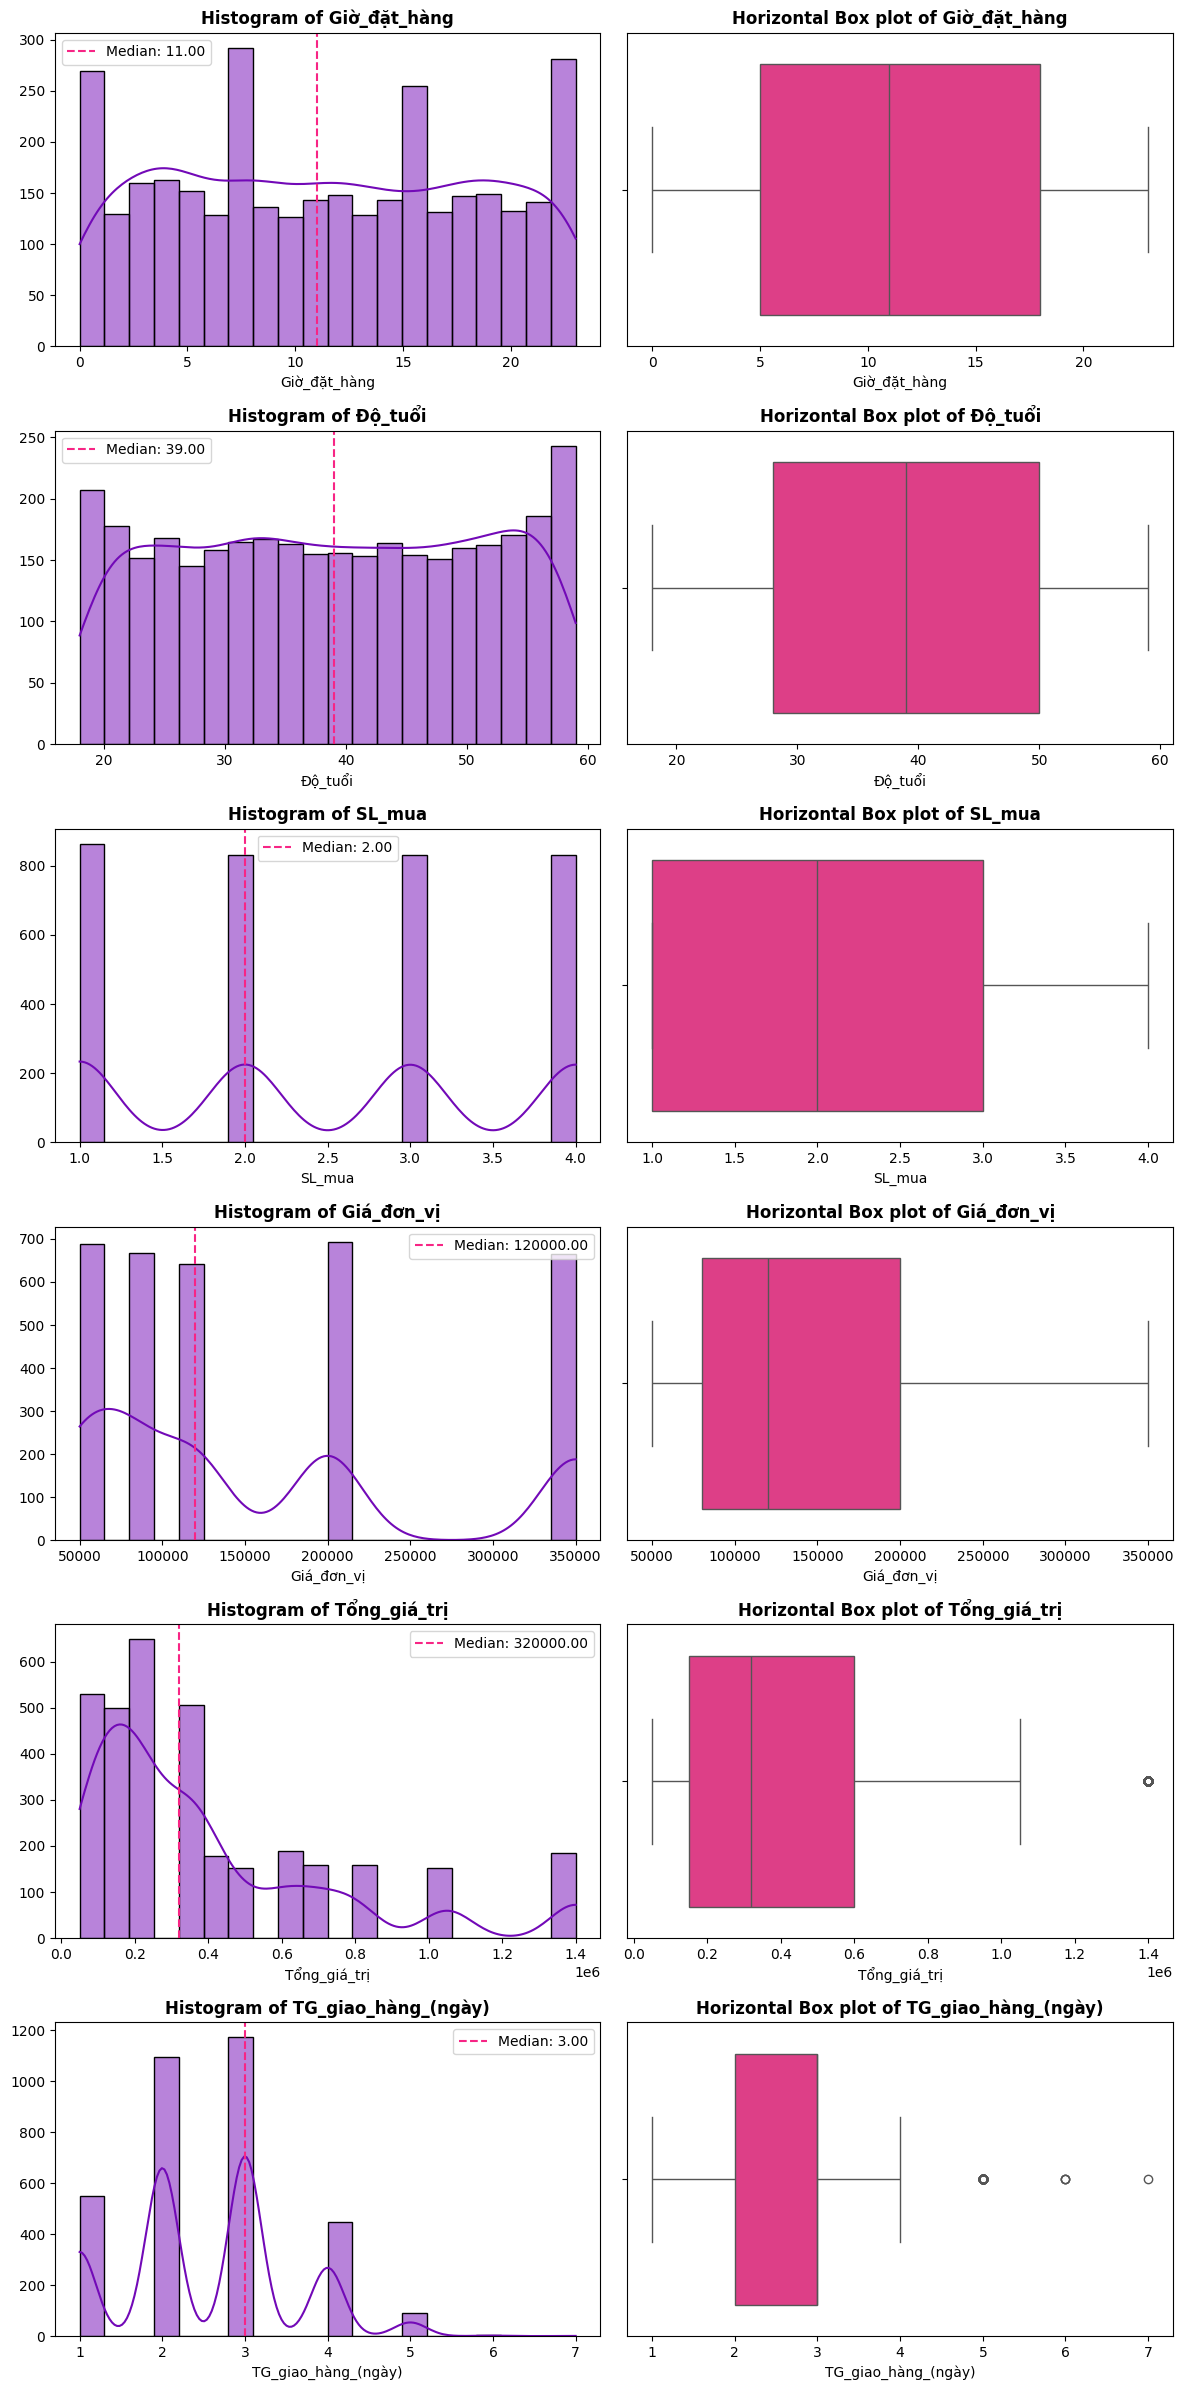

In [182]:
def plot_numerical_features(df=df, numerical_features = num_features):
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        sns.histplot(data=df[feature], color="#7209b7", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature}", weight="bold")
        ax[i, 0].set_ylabel("")
        ax[i, 0].axvline(df[feature].median(), color="#f72585", linestyle="--", label=f"Median: {df[feature].median():.2f}")
        ax[i, 0].legend()
        sns.boxplot(data=df[feature], color="#f72585", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", weight="bold")
        ax[i, 1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [183]:
def check_skewness(data = df, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\n🔍 Skewness for dataset:")
    print("-"*70)
    print(f"{'Feature':<30} | {'Skewness':<10} | {'Remark'}")
    print("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<30} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<30} | {skew:>+10f} | {remark}")
    print("-"*70)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Tổng_giá_trị                   |  +1.483590 | Highly skewed
Giá_đơn_vị                     |  +0.799255 | Moderately skewed
TG_giao_hàng_(ngày)            |  +0.261846 | Approximately symmetric
Giờ_đặt_hàng                   |  +0.033538 | Approximately symmetric
Độ_tuổi                        |  -0.017176 | Approximately symmetric
SL_mua                         |  +0.016700 | Approximately symmetric
----------------------------------------------------------------------


**Numerical Data Overview**

* Most variables are **approximately symmetric**, showing balanced distributions.
* **`Giá_đơn_vị`**: moderately right-skewed → some higher-priced products.
* **`Tổng_giá_trị`**: highly right-skewed → few large transactions with very high total value.
* **`TG_giao_hàng_(ngày)`**: slightly right-skewed → few delayed deliveries (outliers).

**Key Insights**

* Data shows **consistent customer behavior** (age, order time, quantity).
* Skewed features (**`Giá_đơn_vị`, `Tổng_giá_trị`**) may need **transformation or scaling** before clustering.

## Categorical Feature Distributions

In [184]:
def color(n_colors=4):
    # Dải màu mở rộng hơn: tím đậm → tím sáng → hồng → đỏ hồng
    colors = sns.blend_palette(
        ["#3a0ca3", "#4361ee", "#7209b7", "#b5179e", "#f72585"],
        n_colors=n_colors
    )
    return colors


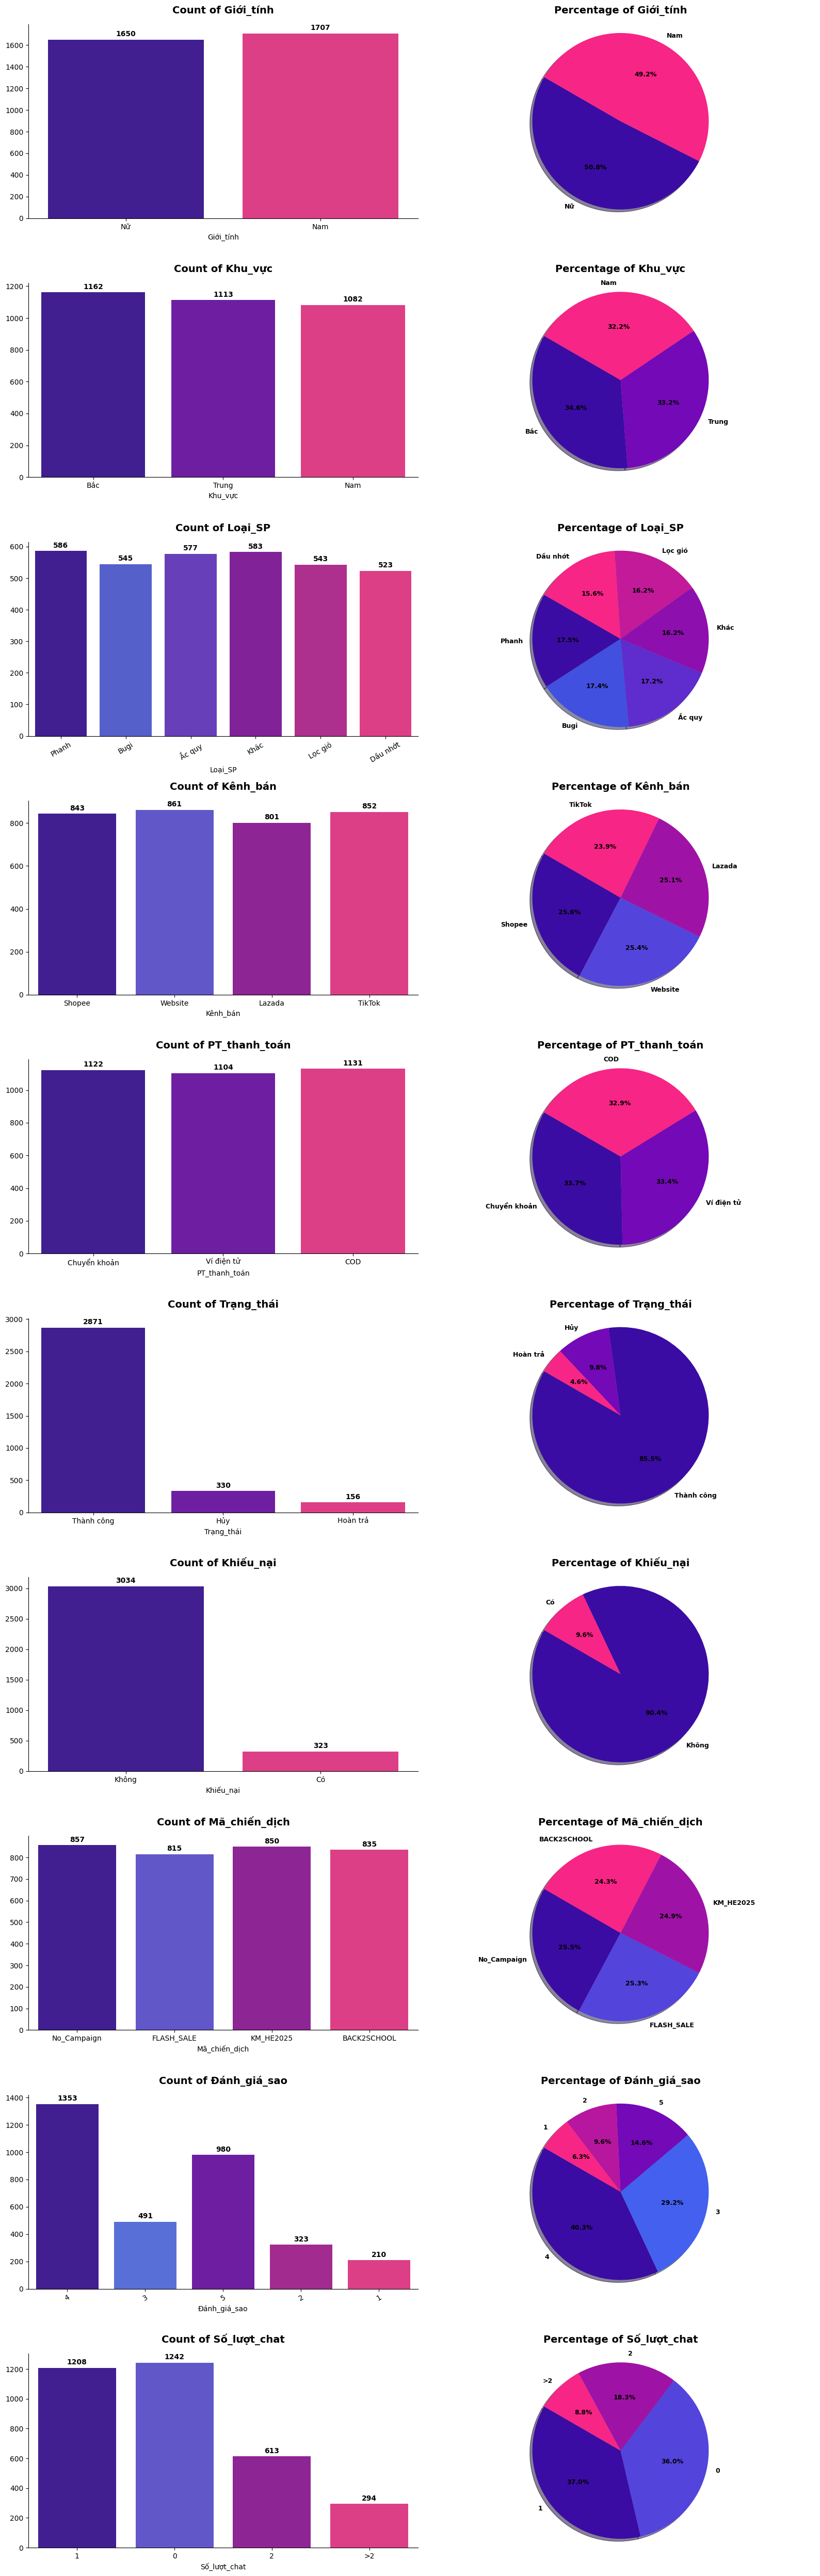

In [185]:
df["Số_lượt_chat"] = df["Số_lượt_chat"].replace({0: "0", 1: "1", 2: "2", 3: ">2", 4: ">2", 5: ">2", 6: ">2", 7: ">2"})
cat_features = ["Giới_tính", "Khu_vực", "Loại_SP", "Kênh_bán", "PT_thanh_toán", "Trạng_thái",
                "Khiếu_nại", "Mã_chiến_dịch", "Đánh_giá_sao", "Số_lượt_chat"]

def plot_categorical_distribution(df, cat_features):
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(16, len(cat_features) * 5))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        order_feature = df[feature].unique().tolist()
        # ----------------------------
        # LEFT: Countplot
        # ----------------------------
        sns.countplot(data=df, x=feature, ax=ax[i, 0], palette=color(n_colors=len(df[feature].unique())), order=order_feature)
        ax[i, 0].set_title(f"Count of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        ax[i, 0].set_ylabel("")
        if len(df[feature].unique()) > 4:
            ax[i, 0].set_xticklabels(ax[i, 0].get_xticklabels(), rotation=30)
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}", ha="center", va="bottom",
                          fontsize=10, fontweight="bold")

        # ----------------------------
        # RIGHT: Pie Chart
        # ----------------------------
        feature_counts = df[feature].value_counts(normalize=True)
        sizes = feature_counts.values * 100  # percentage
        colors = color(n_colors=len(df[feature].unique()))

        wedges, texts, autotexts = ax[i, 1].pie(
            sizes, labels=order_feature, autopct="%1.1f%%", shadow= True,
            startangle=150, colors=colors, textprops={"fontsize": 9, "weight": "bold"}
        )
        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    plt.tight_layout()
    plt.show()
plot_categorical_distribution(df=df, cat_features=cat_features)

**Categorical Feature Insights**

* **Gender:** Balanced between male and female.
* **Region:** Customers mainly from the **North**, others evenly distributed.
* **Product Type:** *Brakes (Phanh)* most purchased among 6 categories.
* **Sales Channel:** Fairly balanced; **Website** and **Shopee** slightly higher.
* **Payment Method:** Majority use **COD**, followed by bank transfer.
* **Order Status:** **Successful orders dominate (~85%)**.
* **Complaints:** Most customers **had no complaints**.
* **Campaign Code:** Several promotions; **KM_HE2025** appears most often.
* **Ratings:** Concentrated around **4 stars**.
* **Chat Count:** Over half of customers **did not chat** before purchase.

**Key Insights**

* Dataset shows **stable operations and high success rate**.
* **COD** and **online sales** dominate → customers prefer **convenient, direct payment methods**.
* Useful for **customer segmentation and satisfaction analysis** later in clustering.

## RFM Analysis

**Customer segmentation based on RFM Score**

| Segment                        | Description                                                                  | RFM Condition    |
| ------------------------------ | ---------------------------------------------------------------------------- | -------------------------- |
| **Champions / Best Customers** | Most valuable customers: recent activity, frequent transactions, high spend. | `R ≥ 4, F ≥ 4, M ≥ 4`      |
| **Loyal Customers**            | Loyal customers: purchase frequently and spend consistently well.            | `F ≥ 4, M ≥ 3`             |
| **Potential Loyalists**        | New customers with decent frequency/spending, potential to become loyal.     | `R ≥ 4, F ≥ 2`             |
| **At Risk**                    | Previously frequent/high spenders but inactive for a long time.              | `R ≤ 2, F ≥ 3`             |
| **New Customers**              | Recently joined, made transactions recently but with low frequency.          | `R ≥ 4, F = 1`             |
| **Hibernating / Churn**        | Customers inactive for a long time with low spending.                        | `R = 1, F = 1, M = 1`      |
| **Others**                     | Customers not falling into the above categories.                             | Different from above rules |


In [186]:
# Convert 2 date columns to datetime type.
df["Ngày_đặt_hàng"] = pd.to_datetime(df["Ngày_đặt_hàng"], format="mixed")

# Define the reference date = the latest transaction date + 1 day
# +1 day is added to avoid Recency = 0 for customers who transacted on the last day
recency_date = df["Ngày_đặt_hàng"].max() + pd.Timedelta(days=1)

# Calculate RFM for each customer (Mã_KH)
rfm_df = df.groupby("Mã_KH").agg({
    # Recency = (reference date - most recent transaction date of the customer)
    "Ngày_đặt_hàng": lambda x: (recency_date - x.max()).days,
    
    # Frequency = number of transactions (count unique TransactionID)
    "SL_mua": "nunique",
    
    # Monetary = total "Tổng_giá_trị"
    "Tổng_giá_trị": "sum"
}).reset_index()

# Rename columns for better readability
rfm_df.columns = ["Mã_KH", "Recency", "Frequency", "Monetary"]

display(rfm_df.head())

,Mã_KH,Recency,Frequency,Monetary
0,KH00001,57,1,160000
1,KH00002,39,1,1400000
2,KH00003,45,1,600000
3,KH00004,47,1,1050000
4,KH00005,24,1,360000


In [187]:
rfm_df["R"] = pd.qcut(rfm_df["Recency"], 5, labels=[5,4,3,2,1])
rfm_df["F"] = pd.qcut(rfm_df["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm_df["M"] = pd.qcut(rfm_df["Monetary"], 5, labels=[1,2,3,4,5])

rfm_df["RFM_Score"] = rfm_df["R"].astype(str) + rfm_df["F"].astype(str) + rfm_df["M"].astype(str)
display(rfm_df.head())

,Mã_KH,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,KH00001,57,1,160000,2,1,2,212
1,KH00002,39,1,1400000,3,1,5,315
2,KH00003,45,1,600000,3,1,4,314
3,KH00004,47,1,1050000,3,1,5,315
4,KH00005,24,1,360000,4,1,4,414


In [188]:
def classify_rfm(row):
    r, f, m = row["R"], row["F"], row["M"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Best Customers"
    elif f >= 4 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r >= 4  and f == 1:
        return "New Customers"
    elif r == 1  and f == 1 and m == 1:
        return "Churn Customers"
    else:
        return "Other"

rfm_df["RFM_Segment"] = rfm_df.apply(classify_rfm, axis=1)
display(rfm_df.head())

,Mã_KH,Recency,Frequency,Monetary,R,F,M,RFM_Score,RFM_Segment
0,KH00001,57,1,160000,2,1,2,212,Other
1,KH00002,39,1,1400000,3,1,5,315,Other
2,KH00003,45,1,600000,3,1,4,314,Other
3,KH00004,47,1,1050000,3,1,5,315,Other
4,KH00005,24,1,360000,4,1,4,414,New Customers


In [189]:
# Create a layout with clear headers, centered text, and nicely formatted numbers
summary_rfm = (
    rfm_df.groupby("RFM_Segment").agg({
        "Recency": ["mean", "min", "max"],
        "Frequency": ["mean", "min", "max"],
        "Monetary": ["mean", "min", "max"],
        "Mã_KH": "count"
    })
    .sort_values(("Monetary", "mean"), ascending=False)
    .style
    .set_caption("RFM Summary by Segment")
    .format(precision=0)  # Round numbers
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold")]}
    ])
    .set_properties(**{
        "text-align": "center",
        "font-size": "12px"
    })
    .background_gradient(subset=[("Recency", "mean"), ("Frequency", "mean"), ("Monetary", "mean"), ("Mã_KH", "count")], cmap="Greens")
)
display(summary_rfm)

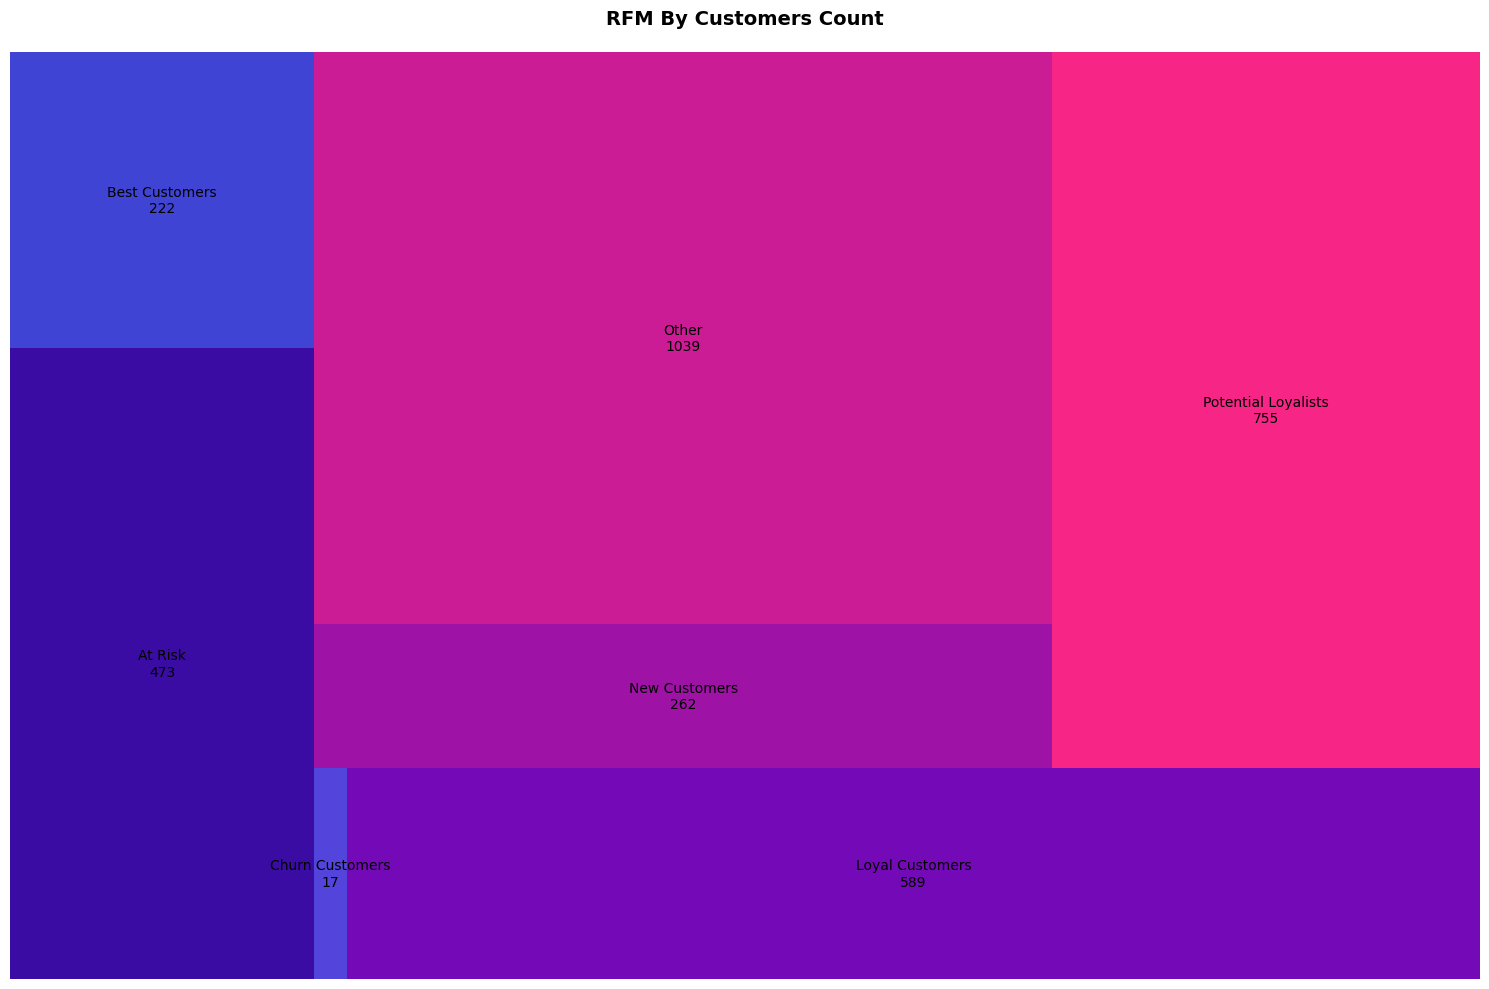

In [190]:
import squarify

rfm_df = rfm_df.astype({
    "R": "int8",
    "F": "int8",
    "M": "int8"
})

rfm_summarised = rfm_df.groupby (by = "RFM_Segment", as_index = False)\
                        .agg (
                            customersCount = ("Mã_KH", "nunique"),
                            total_R = ("R", "sum"),
                            total_F = ("F", "sum"),
                            total_M = ("M", "sum")
                        )

plt.figure(figsize=(15, 10))
squarify.plot(
    rfm_summarised["customersCount"].to_list(),
    label = rfm_summarised["RFM_Segment"] + "\n" + rfm_summarised["customersCount"].astype(str),
    color = color(n_colors=rfm_df["RFM_Segment"].nunique())
)
plt.title ("RFM By Customers Count", fontsize=14, pad=20, weight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

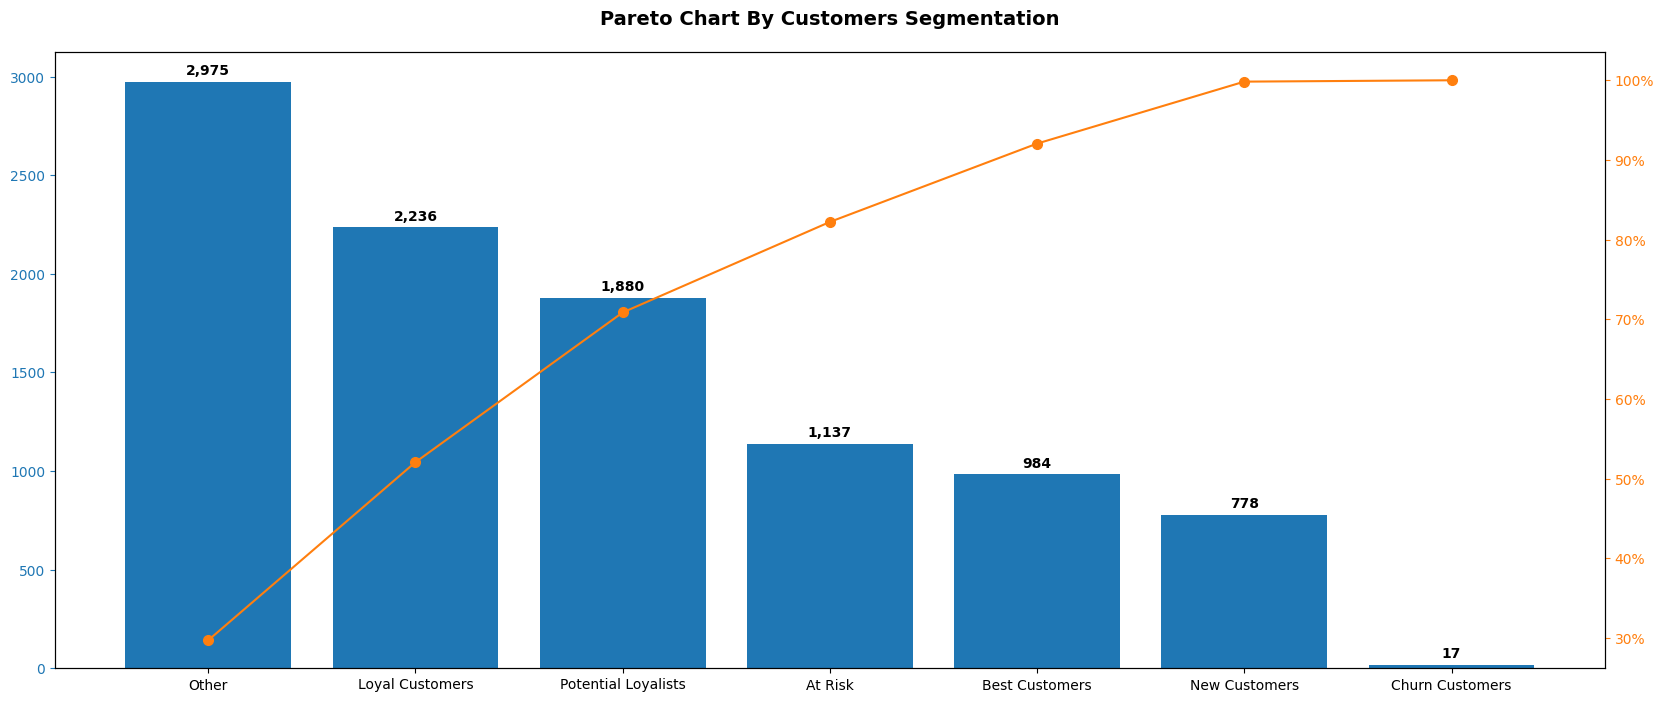

In [191]:
from matplotlib.ticker import PercentFormatter

rfm_summarised = rfm_summarised.sort_values(by="total_M", ascending=False)
rfm_summarised["cumpercentage"] = rfm_summarised["total_M"].cumsum() / rfm_summarised["total_M"].sum() * 100

fig, ax = plt.subplots(figsize=(20, 8))

bars = ax.bar(rfm_summarised["RFM_Segment"], rfm_summarised["total_M"], color="C0")

ax1 = ax.twinx()
ax1.plot(rfm_summarised["RFM_Segment"], rfm_summarised["cumpercentage"], color="C1", marker="o", ms=7)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Add value labels on top of each bar
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in rfm_summarised["total_M"]], padding=3, fontsize=10, color="black", weight="bold")

ax.tick_params(axis="y", colors="C0")
ax1.tick_params(axis="y", colors="C1")

plt.title("Pareto Chart By Customers Segmentation", fontsize=14, pad=20, weight="bold")
plt.show()

**Key Insights**

* Most customers belong to **“Other” (31%)** and **“Potential Loyalists” (22%)** → high conversion potential.
* **Best & Loyal Customers** (~24%) generate the **highest revenue contribution**.
* **At Risk + Churn Customers** (~15%) need focused **retention and recovery campaigns**.

## CLV Analysis

> **CLV = Total profit a customer generates during their relationship with the company.**
> It measures **long-term customer value** and helps optimize **marketing spend, retention, and growth strategy.**

$$
CLV = (Average Purchase Value × Gross Margin) × Purchase Frequency × Lifespan
$$

* **Average Purchase Value × Gross Margin:** Profit per purchase
* **Purchase Frequency:** How often customers buy (e.g., times per year)
* **Lifespan:** Average years a customer stays active
* **Interpretation:** Total lifetime profit from an average customer.

In [192]:
# Compute average purchase value (APV), purchase frequency, and lifespan
clv_df = df.groupby("Mã_KH").agg(
    Total_Revenue=("Tổng_giá_trị", "sum"),
    Num_Transactions=("SL_mua", "nunique"),
    First_Purchase=("Ngày_đặt_hàng", "min"),
    Last_Purchase=("Ngày_đặt_hàng", "max")
).reset_index()

display(clv_df.head())

,Mã_KH,Total_Revenue,Num_Transactions,First_Purchase,Last_Purchase
0,KH00001,160000,1,2025-08-05,2025-08-05
1,KH00002,1400000,1,2025-08-23,2025-08-23
2,KH00003,600000,1,2025-08-17,2025-08-17
3,KH00004,1050000,1,2025-08-15,2025-08-15
4,KH00005,360000,1,2025-09-07,2025-09-07


Average CLV across all customers: 119942.81


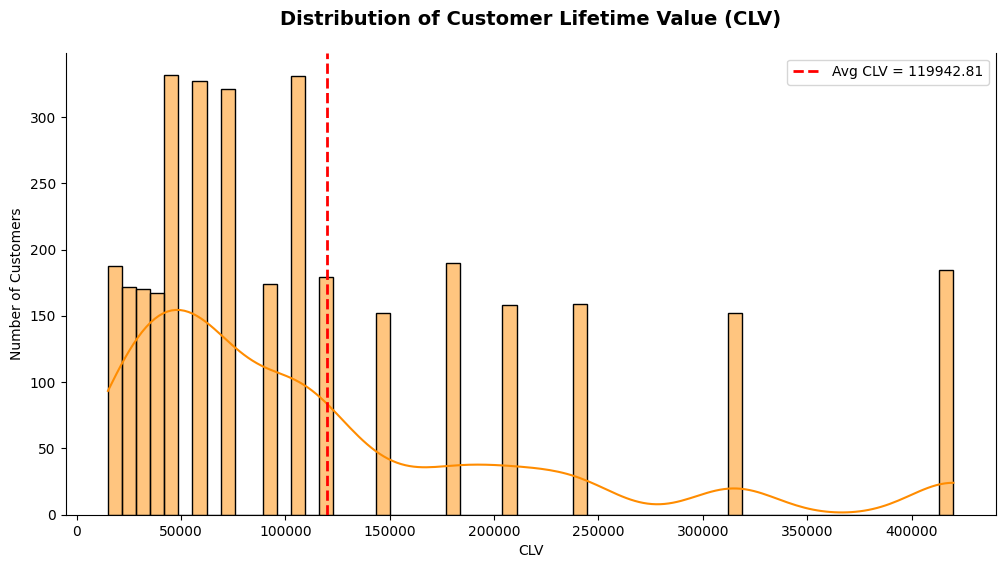

Top 10 High-Value Customers:


,Mã_KH,Total_Revenue,Num_Transactions,First_Purchase,Last_Purchase,APV,Frequency,Lifespan_Months,COGS,GrossMargin,CLV
0,KH01808,1400000,1,2025-09-21,2025-09-21,1400000.0,1,1.0,980000.0,0.3,420000.0
1,KH02861,1400000,1,2025-09-14,2025-09-14,1400000.0,1,1.0,980000.0,0.3,420000.0
2,KH01123,1400000,1,2025-07-20,2025-07-20,1400000.0,1,1.0,980000.0,0.3,420000.0
3,KH00953,1400000,1,2025-09-24,2025-09-24,1400000.0,1,1.0,980000.0,0.3,420000.0
4,KH01845,1400000,1,2025-08-04,2025-08-04,1400000.0,1,1.0,980000.0,0.3,420000.0
5,KH00384,1400000,1,2025-07-12,2025-07-12,1400000.0,1,1.0,980000.0,0.3,420000.0
6,KH02559,1400000,1,2025-09-05,2025-09-05,1400000.0,1,1.0,980000.0,0.3,420000.0
7,KH00333,1400000,1,2025-08-12,2025-08-12,1400000.0,1,1.0,980000.0,0.3,420000.0
8,KH02995,1400000,1,2025-09-08,2025-09-08,1400000.0,1,1.0,980000.0,0.3,420000.0
9,KH02256,1400000,1,2025-09-19,2025-09-19,1400000.0,1,1.0,980000.0,0.3,420000.0


In [193]:
# Average purchase value per transaction
clv_df["APV"] = clv_df["Total_Revenue"] / clv_df["Num_Transactions"]

# Frequency (number of transactions)
clv_df["Frequency"] = clv_df["Num_Transactions"]

# Lifespan: number of months between first and last purchase (+1 to avoid division by zero)
clv_df["Lifespan_Months"] = ((clv_df["Last_Purchase"] - clv_df["First_Purchase"]).dt.days / 30).clip(lower=1)

clv_df["COGS"] = clv_df["Total_Revenue"] * 0.7 # We assume COGS = 70% Total_Revenue.
clv_df["GrossMargin"] = (clv_df["Total_Revenue"] - clv_df["COGS"]) / clv_df["Total_Revenue"]

# Customer Lifetime Value
clv_df["CLV"] = clv_df["APV"] * clv_df["GrossMargin"] * clv_df["Frequency"] * clv_df["Lifespan_Months"]

# --- 2. Calculate the average CLV across all customers ---
avg_clv = clv_df["CLV"].mean()
print(f"Average CLV across all customers: {avg_clv:.2f}")

# --- 3. Plot CLV distribution with Seaborn ---
plt.figure(figsize=(12,6))
sns.histplot(clv_df["CLV"], bins=60, edgecolor="black", kde=True, color="darkorange")
sns.despine(top=True, right=False, left=False, bottom=False)

# Add vertical line for average CLV
plt.axvline(avg_clv, color="red", linestyle="dashed", linewidth=2, label=f"Avg CLV = {avg_clv:.2f}")

# Titles and labels
plt.title("Distribution of Customer Lifetime Value (CLV)", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("CLV")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

# Display top customers with highest CLV (VIP customers)
print("Top 10 High-Value Customers:")
display(clv_df.sort_values(by="CLV", ascending=False).reset_index(drop=True).head(10))

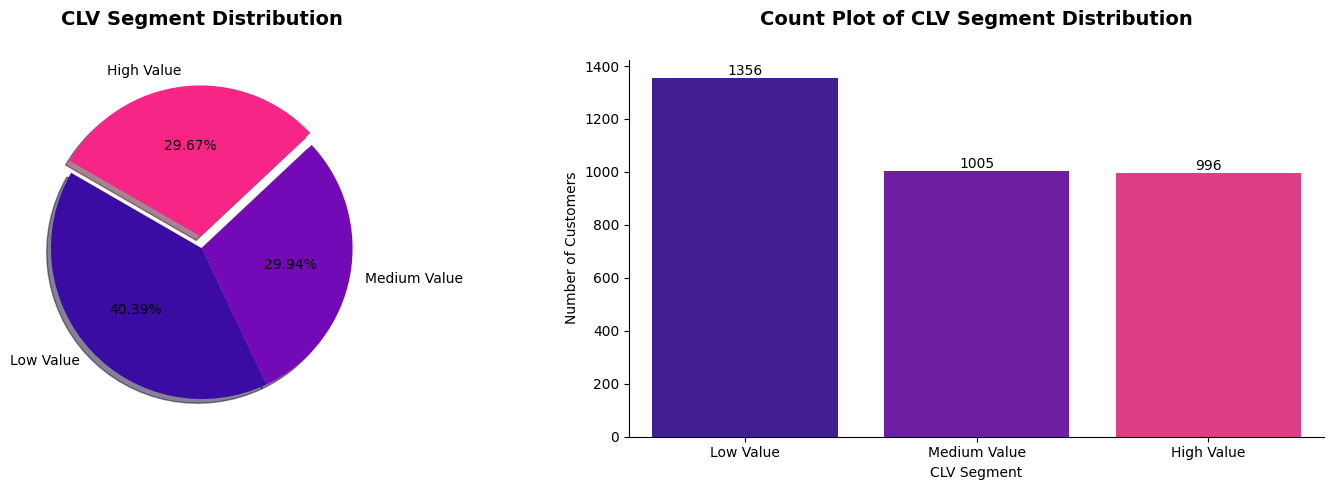

In [194]:
q33 = clv_df["CLV"].quantile(0.33)
q66 = clv_df["CLV"].quantile(0.66)

# Function to classify customers
def clv_segment(x):
    if x <= q33:
        return "Low Value"
    elif x <= q66:
        return "Medium Value"
    else:
        return "High Value"

# Add Segment column
clv_df["CLV_Segment"] = clv_df["CLV"].apply(clv_segment)

# Segment distribution
CLV_Segment_Distribution = clv_df["CLV_Segment"].value_counts()

fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))
n_colors = clv_df["CLV_Segment"].nunique()

# ax[0] – Pie chart
ax[0].pie(CLV_Segment_Distribution, labels=["Low Value", "Medium Value", "High Value"], colors=color(n_colors=3),
          autopct="%1.2f%%", startangle=150, explode=(0, 0, 0.08), shadow=True)
ax[0].set_title("CLV Segment Distribution", weight="bold", fontsize=14, pad=25)

# ax[1] – Count plot
sns.countplot(data=clv_df, x="CLV_Segment", palette=color(n_colors=3), ax=ax[1], order=["Low Value", "Medium Value", "High Value"])
ax[1].set_title("Count Plot of CLV Segment Distribution", weight="bold", fontsize=14, pad=25)
# Add labels on top of bars
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[1].set_ylabel("Number of Customers")
ax[1].set_xlabel("CLV Segment")
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

**Customer Lifetime Value (CLV) Analysis**

* **Average CLV:** ~120K
* **Distribution:** Right-skewed — most customers have low-to-medium lifetime value.
* **Segments:**

  * **Low Value:** 40.4% → majority of customers
  * **Medium Value:** 29.9%
  * **High Value:** 29.7% → small group contributing highest revenue

**Key Insights**

* CLV distribution shows **a small group of high-value customers** driving significant revenue.
* Focus retention and upselling efforts on **High Value** and **Medium Value** groups.
* Consider reactivation or low-cost marketing for **Low Value** customers.

## Let's address some questions
### Phân tích tổng giá trị đơn hàng theo ngày → liệu có tuân theo phân phối chuẩn không?

Skewness: 0.301 - Approximately symmetric
Kurtosis: 2.246 - Heavy/light tails


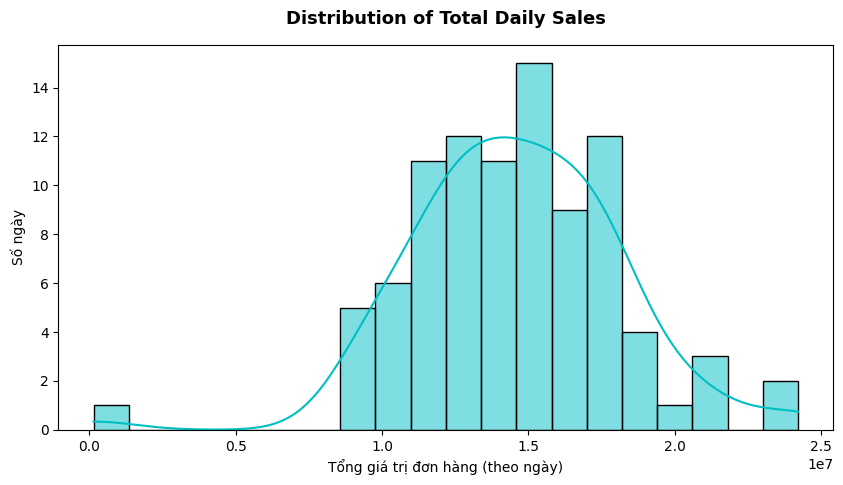

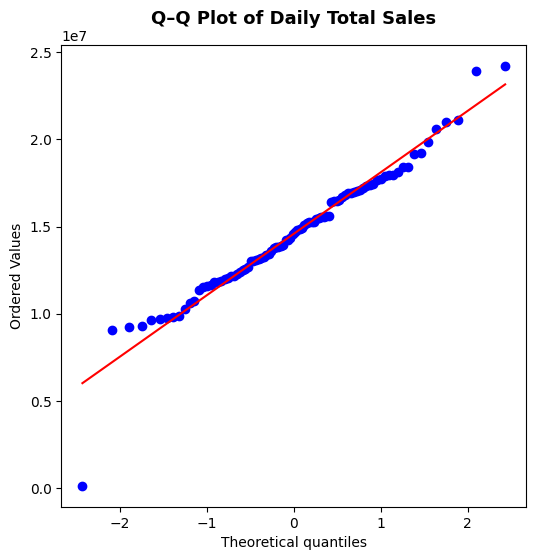

In [195]:
daily_sales = df.groupby("Ngày_đặt_hàng")["Tổng_giá_trị"].sum().reset_index()
skewness = abs(skew(daily_sales["Tổng_giá_trị"]))
kurt = abs(kurtosis(daily_sales["Tổng_giá_trị"]))

# Skewness interpretation
if skewness <= 0.5:
    skew_remark = "Approximately symmetric"
elif skewness <= 1.0:
    skew_remark = "Moderately skewed"
else:
    skew_remark = "Highly skewed"

# Kurtosis interpretation
if kurt < 1.5:
    kurt_remark = "Normal tails"
else:
    kurt_remark = "Heavy/light tails"

print(f"Skewness: {skewness:.3f} - {skew_remark}")
print(f"Kurtosis: {kurt:.3f} - {kurt_remark}")

plt.figure(figsize=(10,5))
sns.histplot(daily_sales["Tổng_giá_trị"], kde=True, color="#00BFC4", bins=20)
plt.title("Distribution of Total Daily Sales", fontsize=13, weight="bold", pad=15)
plt.xlabel("Tổng giá trị đơn hàng (theo ngày)")
plt.ylabel("Số ngày")
plt.show()

plt.figure(figsize=(6,6))
probplot(daily_sales["Tổng_giá_trị"], plot=plt)
plt.title("Q–Q Plot of Daily Total Sales", fontsize=13, weight="bold", pad=15)
plt.show()

**Conclusion:**

The total daily sales **approximately follow a normal distribution**,
indicating that **daily revenue is stable** with **no significant volatility or abnormal outliers**.

### Phân tích thời gian giao hàng (ngày) → dữ liệu có tập trung quanh mức trung bình 3 ngày không?

In [196]:
df["TG_giao_hàng_(ngày)"].describe()

count    3357.000000
mean        2.536193
std         1.008730
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         7.000000
Name: TG_giao_hàng_(ngày), dtype: float64

**Insight**

The data is **not perfectly centered around 3 days** —
→ Possible **operational or logistics inefficiencies** causing delayed deliveries in certain cases.

### Xác suất một đơn hàng có khiếu nại (Có/Không)?

In [197]:
from scipy.stats import norm

def complaint_stats(df, complaint_col="Khiếu_nại", yes_value="Có", ci=0.95):
    # overall
    p = (df[complaint_col] == yes_value).mean()
    n = df[complaint_col].notna().sum()
    z = norm.ppf(0.5 + ci/2)
    se = (p*(1-p)/n)**0.5
    ci_low, ci_high = p - z*se, p + z*se
    print(f"Complaint rate (overall): {p:.3%}  |  {ci:.0%} CI: [{ci_low:.3%}, {ci_high:.3%}]  (n={n})")

complaint_by_channel = complaint_stats(df)

Complaint rate (overall): 9.622%  |  95% CI: [8.624%, 10.619%]  (n=3357)


**Answer**
> The overall complaint rate is around **9.6%**, stable within the range of **8.6–10.6%**.
> → Indicates **generally good service quality**, though **specific products or sales channels with higher risk should be monitored**.

### Tỷ lệ khách hàng mua lại từ một chiến dịch marketing cụ thể (Yes/No)?

In [198]:
def repurchase_rate_from_campaign(
    df,
    campaign_code,
    customer_col="Mã_KH",
    date_col="Ngày_đặt_hàng",
    campaign_col="Mã_chiến_dịch",
    window_days=90  # time window (in days) to calculate repurchase after the campaign
):
    # Convert the date column to datetime type
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    
    # Filter customers who participated in the specific campaign
    campaign_df = df[df[campaign_col] == campaign_code]
    
    # Get each customer’s first purchase date within the campaign
    first_campaign_date = (
        campaign_df.groupby(customer_col)[date_col]
                   .min()
                   .rename("first_campaign_date")
                   .reset_index()
    )
    
    # Get all transactions of those customers
    merged = df.merge(first_campaign_date, on=customer_col, how="right")
    
    # Check if customers made another purchase after that (within window_days)
    repurchased = (
        merged[
            (merged[date_col] > merged["first_campaign_date"]) &
            (merged[date_col] <= merged["first_campaign_date"] + pd.Timedelta(days=window_days))
        ]
        .groupby(customer_col)
        .size()
        .gt(0)
        .rename("Repurchased")
        .reset_index()
    )
    
    # Merge with the list of campaign customers
    result = first_campaign_date[[customer_col]].merge(repurchased, on=customer_col, how="left").fillna(False)
    
    # Calculate the repurchase rate
    repurchase_rate = result["Repurchased"].mean()
    total_customers = len(result)
    
    print(f"Repurchase rate for campaign '{campaign_code}' within {window_days} days: {repurchase_rate:.2%} (n={total_customers})")
    return result

# 👉 Example:
rep_df = repurchase_rate_from_campaign(
    df,
    campaign_code="KM_HE2025",  # specific campaign code
    window_days=60               # example: calculate repurchase within 60 days
)

Repurchase rate for campaign 'KM_HE2025' within 60 days: 0.00% (n=850)


### Số review/ngày có tuân theo phân phối Poisson không?

λ (average reviews/day): 36.49


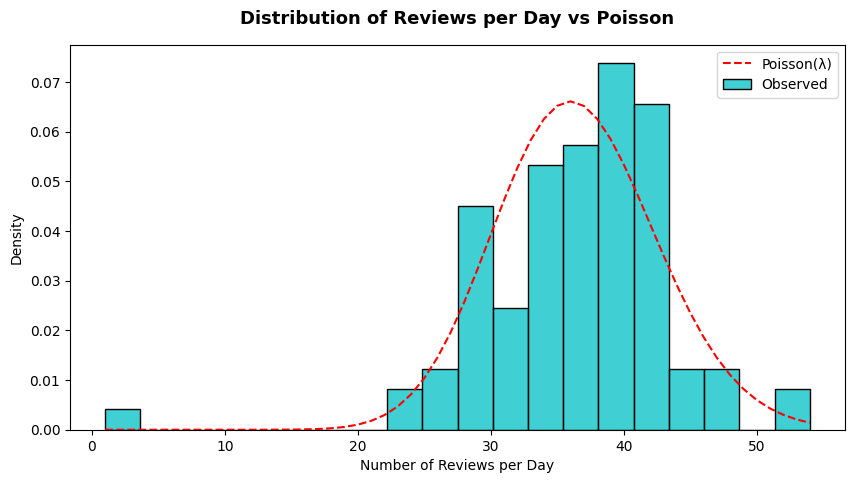

Chi-square test: χ²=1955842268361.609, p=0.0000
❌ The number of reviews per day does NOT follow a Poisson distribution.


In [199]:
from scipy.stats import poisson, chisquare

review_per_day = df.groupby("Ngày_đặt_hàng")["Đánh_giá_sao"].count().reset_index(name="review_count")

# Tính λ = số review trung bình/ngày
lambda_ = review_per_day["review_count"].mean()
print(f"λ (average reviews/day): {lambda_:.2f}")

# So sánh phân phối thực tế và Poisson theoretical
plt.figure(figsize=(10,5))
sns.histplot(review_per_day["review_count"], bins=20, kde=False, color="#00BFC4", stat="density", label="Observed")
x = range(int(review_per_day["review_count"].min()), int(review_per_day["review_count"].max()) + 1)
plt.plot(x, poisson.pmf(x, mu=lambda_), "r--", label="Poisson(λ)")
plt.title("Distribution of Reviews per Day vs Poisson", fontsize=13, weight="bold", pad=15)
plt.xlabel("Number of Reviews per Day")
plt.ylabel("Density")
plt.legend()
plt.show()

# Kiểm định goodness-of-fit (xấp xỉ)
# Tính phân phối quan sát
observed = review_per_day["review_count"].value_counts().sort_index()
# Tính phân phối kỳ vọng Poisson
expected = [poisson.pmf(k, mu=lambda_) * len(review_per_day) for k in observed.index]
# Chuẩn hóa expected để tổng khớp observed
expected = np.array(expected)
expected *= observed.sum() / expected.sum()

# Kiểm định chi-square
chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
print(f"Chi-square test: χ²={chi_stat:.3f}, p={p_value:.4f}")
if p_value > 0.05:
    print("✅ The number of reviews per day follows a Poisson distribution.")
else:
    print("❌ The number of reviews per day does NOT follow a Poisson distribution.")

### Số lượt chat hỗ trợ/giờ → áp dụng mô hình Poisson để dự đoán peak load.

λ (average chats/hour): 139.88
Probability of exceeding 160 chats/hour: 5.087%


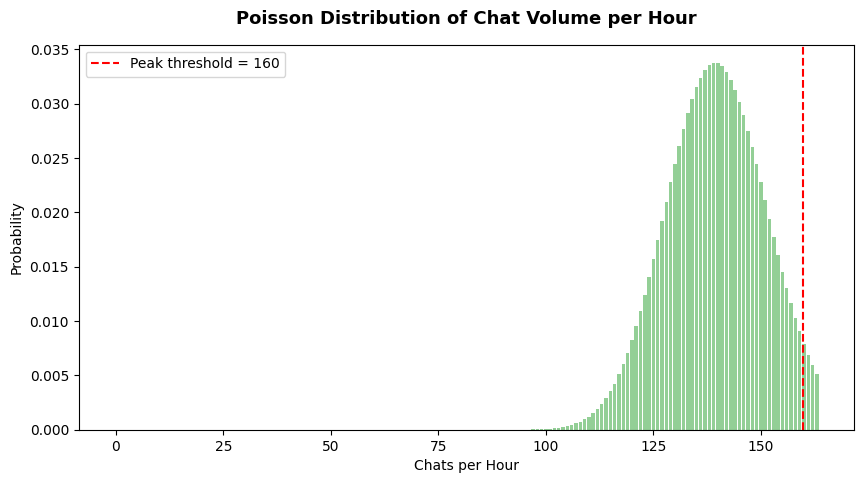

In [200]:
# Đếm số lượt chat mỗi giờ
chat_per_hour = df.groupby("Giờ_đặt_hàng")["Số_lượt_chat"].count().reset_index(name="chat_count")

# Ước lượng λ = số lượt chat trung bình/giờ
lambda_chat = chat_per_hour["chat_count"].mean()
print(f"λ (average chats/hour): {lambda_chat:.2f}")

# Xác suất số lượt chat vượt ngưỡng (peak)
threshold = np.percentile(chat_per_hour["chat_count"], 95)
prob_peak = 1 - poisson.cdf(threshold, mu=lambda_chat)
print(f"Probability of exceeding {threshold:.0f} chats/hour: {prob_peak:.3%}")

# Vẽ phân phối
x = np.arange(0, int(chat_per_hour["chat_count"].max()) + 1)
plt.figure(figsize=(10,5))
plt.bar(x, poisson.pmf(x, mu=lambda_chat), color="#4CAF50", alpha=0.6)
plt.axvline(threshold, color='red', linestyle='--', label=f"Peak threshold = {threshold:.0f}")
plt.title("Poisson Distribution of Chat Volume per Hour", fontsize=13, weight="bold", pad=15)
plt.xlabel("Chats per Hour")
plt.ylabel("Probability")
plt.legend()
plt.show()

### Kiểm định mối quan hệ giữa loại sản phẩm và mức đánh giá sao.

In [201]:
import pandas as pd
import scipy.stats as stats

# Create a contingency table between Loại_SP and Đánh_giá_sao
contingency_table = pd.crosstab(df["Loại_SP"], df["Đánh_giá_sao"])

# Perform Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square test between Loại_SP and Đánh_giá_sao:")
print(f"Chi2 = {chi2:.3f}, p-value = {p:.4f}")

if p < 0.05:
    print("There is a statistically significant relationship between Loại_SP and Đánh_giá_sao.")
else:
    print("There is no significant relationship between Loại_SP and Đánh_giá_sao.")

Chi-square test between Loại_SP and Đánh_giá_sao:
Chi2 = 17.697, p-value = 0.6074
There is no significant relationship between Loại_SP and Đánh_giá_sao.


### Kiểm định mối quan hệ giữa giới tính khách hàng và kênh bán hàng (Shopee, TikTok, Lazada…).

In [202]:
# Create a contingency table between Giới_tính and Star Rating
contingency_table = pd.crosstab(df["Giới_tính"], df["Kênh_bán"])

# Perform Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square test between Giới_tính and Kênh_bán:")
print(f"Chi2 = {chi2:.3f}, p-value = {p:.4f}")

if p < 0.05:
    print("There is a statistically significant relationship between Giới_tính and Kênh_bán.")
else:
    print("There is no significant relationship between Giới_tính and Kênh_bán.")

Chi-square test between Giới_tính and Kênh_bán:
Chi2 = 1.291, p-value = 0.7314
There is no significant relationship between Giới_tính and Kênh_bán.


### So sánh trung bình giá trị đơn hàng trước & sau khuyến mãi (two-sample t-test).

In [203]:
# Split data before and after the promotion
before = df[df["Mã_chiến_dịch"] == "No_Campaign"]["Tổng_giá_trị"]
after = df[df["Mã_chiến_dịch"] != "No_Campaign"]["Tổng_giá_trị"]

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(before, after, equal_var=False)

print(f"T-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("There is a statistically significant difference between the two groups — the promotion affects order value.")
else:
    print("No significant difference — the promotion does not have much impact on order value.")

T-statistic = 0.983, p-value = 0.3257
No significant difference — the promotion does not have much impact on order value.


### So sánh thời gian giao hàng giữa khu vực Bắc & Nam (independent t-test).

In [204]:
# Split data by two region
before = df[df["Khu_vực"] == "Bắc"]["TG_giao_hàng_(ngày)"]
after = df[df["Khu_vực"] != "Nam"]["TG_giao_hàng_(ngày)"]

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(before, after, equal_var=False)

print(f"T-statistic = {t_stat:.3f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("There is a significant difference in delivery time between the North and the South.")
else:
    print("No significant difference between the two regions.")

T-statistic = 0.505, p-value = 0.6133
No significant difference between the two regions.


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Re-check and Handling Skew

In [205]:
skew_feature, skew_df = check_skewness(data=df, numerical_features=num_features)


🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Tổng_giá_trị                   |  +1.483590 | Highly skewed
Giá_đơn_vị                     |  +0.799255 | Moderately skewed
TG_giao_hàng_(ngày)            |  +0.261846 | Approximately symmetric
Giờ_đặt_hàng                   |  +0.033538 | Approximately symmetric
Độ_tuổi                        |  -0.017176 | Approximately symmetric
SL_mua                         |  +0.016700 | Approximately symmetric
----------------------------------------------------------------------


In [206]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None
    
):
    """
    Handle skewed numerical features by applying appropriate transformations,
    *forcing* certain columns to be transformed even if they don't exceed skew_threshold.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely
    - dataset: Name of dataset

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    - pt_dict: dict mapping each YJ‑transformed col → its PowerTransformer
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))
    print(to_transform)

    transformed_cols = []
    dropped_cols     = []
    pt_dict          = {}

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            pt_dict[col] = pt
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed, pt_dict

In [207]:
processed_df, transformed_columns, sparse_columns, skewed_columns, pt_dict = handle_skewed_features(df=df, num_features=skew_feature)
num_features = ["Giờ_đặt_hàng", "Độ_tuổi", "SL_mua", "Giá_đơn_vị", "PT_Tổng_giá_trị", "TG_giao_hàng_(ngày)"]
skew_feature, skew_df = check_skewness(data=processed_df, numerical_features=num_features)

['Tổng_giá_trị', 'Giá_đơn_vị']

🔍 Skewness for dataset:
----------------------------------------------------------------------
Feature                        | Skewness   | Remark
----------------------------------------------------------------------
Giá_đơn_vị                     |  +0.799255 | Moderately skewed
TG_giao_hàng_(ngày)            |  +0.261846 | Approximately symmetric
Giờ_đặt_hàng                   |  +0.033538 | Approximately symmetric
Độ_tuổi                        |  -0.017176 | Approximately symmetric
SL_mua                         |  +0.016700 | Approximately symmetric
PT_Tổng_giá_trị                |  -0.004537 | Approximately symmetric
----------------------------------------------------------------------


***Most numerical variables are roughly symmetric. Only Unit_Price shows moderate right skewness, which may slightly affect regression or classification models.***

## Re-check Outliers

In [208]:
checking_outlier(list_feature=num_features, df=processed_df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,TG_giao_hàng_(ngày),93


***Because the outliers account for only a small proportion, you can safely apply **StandardScaler** directly without trimming or replacing any values.***

## Scale and Encoding

In [209]:
import time

processed_df["Ngày_đặt_hàng"] = pd.to_datetime(processed_df["Ngày_đặt_hàng"], format="%Y-%m-%d")
processed_df["Ngày_đặt_hàng"] = processed_df["Ngày_đặt_hàng"].apply(lambda x: int(time.mktime(x.timetuple())))

In [210]:
num_features = ["Giờ_đặt_hàng", "Độ_tuổi", "SL_mua", "Giá_đơn_vị", "PT_Tổng_giá_trị", "TG_giao_hàng_(ngày)", "Ngày_đặt_hàng"]
X = processed_df[num_features + cat_features].copy()

# There are no **missing values** in dataset. But we will still handle missing values ​​to check the data in the future.
num_standard_scaler_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # Handling Text and Categorical Attributes
])

preprocessor = ColumnTransformer(transformers=[
    ("num_standard", num_standard_scaler_transformer, num_features),
    ("cat_onehot", cat_onehot_transformer, cat_features)
])

preprocessor.fit(X)
X_prepared = preprocessor.transform(X)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("cat_onehot__", "").replace("PT_", "") for col in list_feature_prepared]

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>


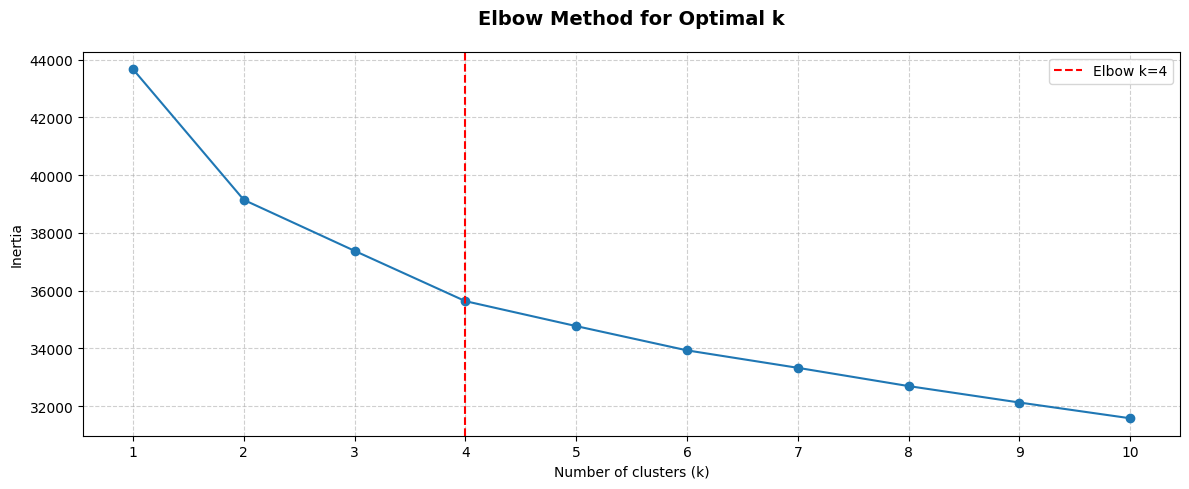

Optimal k suggested by Elbow: 4


In [211]:
# If X_prepared is sparse, convert to dense
X_use = X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared

# --- Elbow Method ---
inertia = []
K_elbow = range(1, 11)  # k = 1..10
for k in K_elbow:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_use)
    inertia.append(kmeans.inertia_)

# Find the elbow point
kneedle = KneeLocator(list(K_elbow), inertia, curve="convex", direction="decreasing")
k_best_elbow = kneedle.knee

# Plot Elbow
plt.figure(figsize=(12, 5))
plt.plot(list(K_elbow), inertia, marker="o", linestyle="-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k", fontsize=14, pad=20, weight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(1, 11))

# Mark elbow if found
if k_best_elbow is not None:
    plt.axvline(k_best_elbow, linestyle="--", label=f"Elbow k={k_best_elbow}", color = "red")
    plt.legend()

plt.tight_layout()
plt.show()

print(f"Optimal k suggested by Elbow: {k_best_elbow}")

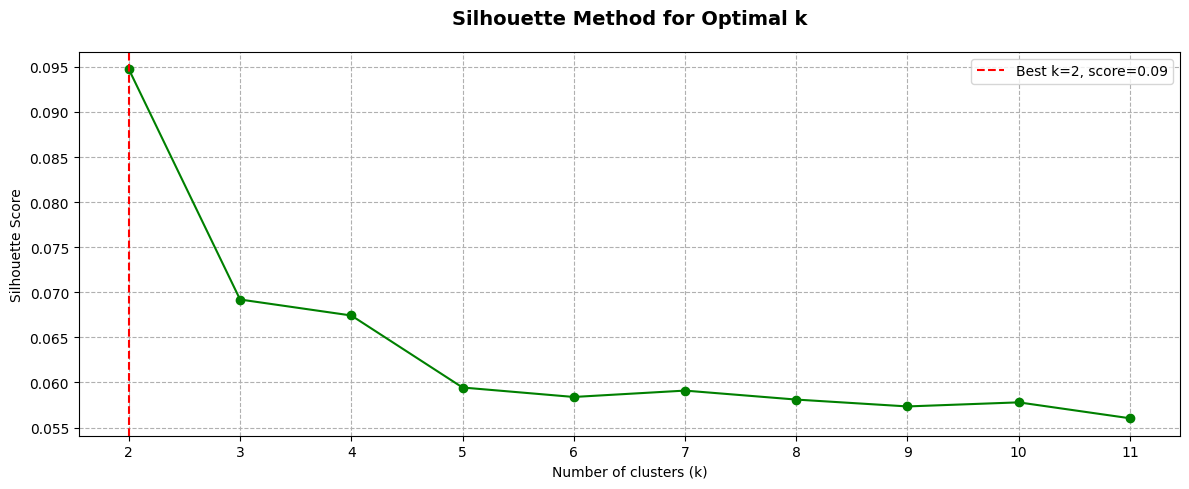

Optimal k suggested by Silhouette: 2


In [212]:
from sklearn.metrics import silhouette_score

# --- Silhouette Method ---
silhouette_scores = []
K_silhouette = range(2, 12)  # Silhouette score cannot be computed for k=1

# Loop through different k values
for k in K_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_use)
    score = silhouette_score(X_use, labels)
    silhouette_scores.append(score)

# Find k with the highest silhouette score
best_k_silhouette = K_silhouette[silhouette_scores.index(max(silhouette_scores))]

# Plot Silhouette results
plt.figure(figsize=(12, 5))
plt.plot(list(K_silhouette), silhouette_scores, marker="o", linestyle="-", color="green")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal k", fontsize=14, pad=20, weight="bold")
plt.grid(True, linestyle="--")
plt.xticks(range(2, 12))

# Highlight the best silhouette score
plt.axvline(best_k_silhouette, linestyle="--", color="red",
            label=f"Best k={best_k_silhouette}, score={max(silhouette_scores):.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal k suggested by Silhouette: {best_k_silhouette}")

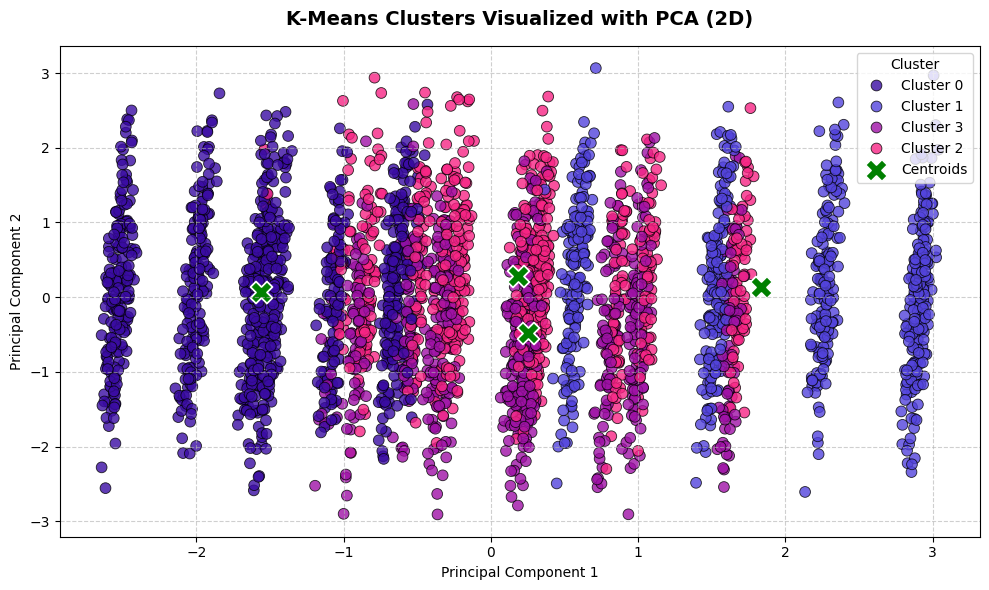

In [215]:
# Fit K-means with the chosen number of clusters (k=4 following Elbow Method)
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
kmeans.fit(X_use)

# Assign clusters and calculate distance to cluster centroid
df["Cluster"] = kmeans.labels_
df["DistanceToCentroid"] = np.linalg.norm(X_use - kmeans.cluster_centers_[kmeans.labels_], axis=1)
df["Cluster"] = df["Cluster"].replace({0: "Cluster 0", 1: "Cluster 1",2: "Cluster 2", 3: "Cluster 3"})

# --- PCA Visualization using Seaborn ---
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_use)

# Add PCA components to dataframe
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# Create figure
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette=color(n_colors=4), s=60,
                alpha=0.8, edgecolor="black")

# Plot centroids (transformed into PCA space)
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(x=centroids_pca[:, 0], y=centroids_pca[:, 1], s=250, color="green", marker="X", label="Centroids")

# Formatting
plt.title("K-Means Clusters Visualized with PCA (2D)", fontsize=14, weight="bold", pad=15)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**K-Means Clustering (PCA 2D Visualization)**

* The chart shows **4 customer clusters** generated by the **K-Means algorithm**, visualized in 2D space using PCA.
* The colors (from deep purple to pink) indicate **moderate separation** among clusters, with **slight overlap** between clusters 1 and 2.
* **Centroids (green “X” markers)** represent the cluster centers — evenly distributed and non-overlapping, suggesting that K-Means converged properly.
* PCA reduces dimensions, so the separation visible here reflects the **main grouping tendencies**, though some overlap may still exist in the original feature space.

**Summary:**

> The data shows clear segmentation trends in the PCA-reduced space. Clusters are distinguishable enough for further **customer segmentation analysis** (e.g., behavior, value, or loyalty insights).